# Task 1. Data preparation and customer analytics

### Background information:
You are part of Quantium’s retail analytics team. Your client, the Chips Category Manager, wants to understand chip customers and their purchasing behavior in the region. The insights derived from this analysis will inform the supermarket’s strategic plan for the chip category over the next six months.

**key objectives:**

*   Analyze transaction and customer data to identify trends and inconsistencies.

*   Develop metrics and examine sales drivers to gain insights into overall sales performance.

*   Create visualizations and prepare findings to formulate a clear recommendation for the client's strategy.



## Load and inspect the data

Load the transaction data in `"transaction_data.xlsx"`and the customer data `customer_data.csv` from google drive into a pandas DataFrame and inspect the initial rows, data types, and basic statistics to get an overview of the dataset.


In [ ]:
# Import and mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import pandas as pd

# Create a file path for the Excel file in drive
file_path_1 = "/content/drive/MyDrive/Forage Virtual Internships/Quantium/transaction_data.xlsx"
file_path_2 = "/content/drive/MyDrive/Forage Virtual Internships/Quantium/customer_data.csv"

# Read the Excel file into a pandas DataFrame
df_transaction = pd.read_excel(file_path_1)
df_customer = pd.read_csv(file_path_2)

# Display the first 5 rows
print("First 5 rows of the DataFrames:")
display(df_transaction.head())
display(df_customer.head())

# Print the data types of each column
print("\nData types of each column:")
print(df_transaction.dtypes, '\n')
print(df_customer.dtypes)

# Print the number of rows and columns in each dataframe
print("\nNumber of rows and columns in each dataframe:")
print(f'There are {df_transaction.shape[0]} rows and {df_transaction.shape[1]} columns in transaction data')
print(f'There are {df_customer.shape[0]} rows and {df_customer.shape[1]} columns in customer data')

# Generate descriptive statistics for numerical columns
print("\nDescriptive statistics for numerical columns:")
display(df_transaction.describe())
display(df_customer.describe())

First 5 rows of the DataFrames:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
1,2019-05-14,1,1307,348,66,CCs Nacho Cheese 175g,3,6.3
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8


,LYLTY_CARD_NBR,LIFESTAGE,PREMIUM_CUSTOMER
0,1000,YOUNG SINGLES/COUPLES,Premium
1,1002,YOUNG SINGLES/COUPLES,Mainstream
2,1003,YOUNG FAMILIES,Budget
3,1004,OLDER SINGLES/COUPLES,Mainstream
4,1005,MIDAGE SINGLES/COUPLES,Mainstream



Data types of each column:
DATE              datetime64[ns]
STORE_NBR                  int64
LYLTY_CARD_NBR             int64
TXN_ID                     int64
PROD_NBR                   int64
PROD_NAME                 object
PROD_QTY                   int64
TOT_SALES                float64
dtype: object 

LYLTY_CARD_NBR       int64
LIFESTAGE           object
PREMIUM_CUSTOMER    object
dtype: object

Number of rows and columns in each dataframe:
There are 264836 rows and 8 columns in transaction data
There are 72637 rows and 3 columns in customer data

Descriptive statistics for numerical columns:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_QTY,TOT_SALES
count,264836,264836.00000,2.648360e+05,2.648360e+05,264836.000000,264836.000000,264836.000000
mean,2018-12-30 00:52:12.879215616,135.08011,1.355495e+05,1.351583e+05,56.583157,1.907309,7.304200
min,2018-07-01 00:00:00,1.00000,1.000000e+03,1.000000e+00,1.000000,1.000000,1.500000
25%,2018-09-30 00:00:00,70.00000,7.002100e+04,6.760150e+04,28.000000,2.000000,5.400000
50%,2018-12-30 00:00:00,130.00000,1.303575e+05,1.351375e+05,56.000000,2.000000,7.400000
75%,2019-03-31 00:00:00,203.00000,2.030942e+05,2.027012e+05,85.000000,2.000000,9.200000
max,2019-06-30 00:00:00,272.00000,2.373711e+06,2.415841e+06,114.000000,200.000000,650.000000
std,NaN,76.78418,8.057998e+04,7.813303e+04,32.826638,0.643654,3.083226


,LYLTY_CARD_NBR
count,7.263700e+04
mean,1.361859e+05
std,8.989293e+04
min,1.000000e+03
25%,6.620200e+04
50%,1.340400e+05
75%,2.033750e+05
max,2.373711e+06


## Filter for chips products

Create a new DataFrame containing only the transactions where the `PROD_NAME` indicates a chips product. To filter for chips products, I will create a list of keywords commonly found in chips product names and then filter the DataFrame to include only the rows where the `PROD_NAME` contains any of these keywords (case-insensitive).

In [ ]:
# Define keywords related to chips
chips_keywords = ['chip', 'chips', 'crisps', 'corn', 'tortilla']

# Filter the DataFrame for rows where PROD_NAME contains any of the keywords
# Using case=False for case-insensitive matching
df_chips = df_transaction[df_transaction['PROD_NAME'].str.contains('|'.join(chips_keywords), case=False)].copy()

# Display the first few rows of the filtered DataFrame
print("\nFirst 5 rows of the filtered DataFrame (chips products):")
display(df_chips.head())

# Display the number of rows in the filtered DataFrame
print(f"\nNumber of transactions after filtering for chips products: {len(df_chips)}")


First 5 rows of the filtered DataFrame (chips products):


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0
2,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9
3,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0
4,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8
6,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7



Number of transactions after filtering for chips products: 99942


## Check for missing values and inconsistencies

Identify any missing values or inconsistencies  in the dataset using the `.isnull().sum()` method and handle them appropriately.

In [ ]:
# Check for missing values
print("\nMissing values in each column:")
print(df_chips.isnull().sum(), '\n')
print(df_customer.isnull().sum())


Missing values in each column:
DATE              0
STORE_NBR         0
LYLTY_CARD_NBR    0
TXN_ID            0
PROD_NBR          0
PROD_NAME         0
PROD_QTY          0
TOT_SALES         0
dtype: int64 

LYLTY_CARD_NBR      0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64


## Examine product names for category consistency

Analyze the `PROD_NAME` column to ensure product categories are correctly identified and look for any variations or errors. This will help identify any inconsistencies, spelling errors, or variations in how product names are recorded.

In [ ]:
# Get unique product names
unique_prod_names = df_chips['PROD_NAME'].unique()

# Display the number of unique product names and a sample
print(f"\nNumber of unique product names: {len(unique_prod_names)}")
print("\nSample of unique product names:")
print(unique_prod_names[:20]) # Displaying the first 20 for brevity


Number of unique product names: 42

Sample of unique product names:
['Natural Chip        Compny SeaSalt175g'
 'Smiths Crinkle Cut  Chips Chicken 170g'
 'Smiths Chip Thinly  S/Cream&Onion 175g'
 'Kettle Tortilla ChpsHny&Jlpno Chili 150g'
 'Smiths Crinkle Chips Salt & Vinegar 330g'
 'Doritos Corn Chip Mexican Jalapeno 150g'
 'Thins Chips Light&  Tangy 175g'
 'Doritos Corn Chip Southern Chicken 150g'
 'Smiths Chip Thinly  Cut Original 175g'
 'Thins Chips         Originl saltd 175g'
 'Natural ChipCo      Hony Soy Chckn175g'
 'Dorito Corn Chp     Supreme 380g' 'Thins Chips Seasonedchicken 175g'
 'Tyrrells Crisps     Lightly Salted 165g'
 'Doritos Corn Chips  Original 170g'
 'Cobs Popd Swt/Chlli &Sr/Cream Chips 110g'
 'Natural Chip Co     Tmato Hrb&Spce 175g'
 'Smiths Crinkle Cut  Chips Original 170g'
 'Cobs Popd Sea Salt  Chips 110g'
 'Smiths Crinkle Cut  Chips Chs&Onion170g']


## Identify and handle outliers

Detect outliers in numeric columns that could skew the analysis and decide on an appropriate strategy for handling them (e.g. removal or transformation).
To understand the sales performance and customer purchasing behavior for chips products, I will calculate descriptive statistics for the `PROD_QTY` and `TOT_SALES` columns in the filtered DataFrame. I will also look at the distribution of these columns.

In [ ]:
# Display descriptive statistics for PROD_QTY and TOT_SALES in the filtered DataFrame
print("\nDescriptive statistics for PROD_QTY and TOT_SALES (chips products):")
display(df_chips[['PROD_QTY', 'TOT_SALES']].describe())

# Analyze the distribution of PROD_QTY
print("\nDistribution of PROD_QTY (chips products):")
print(df_chips['PROD_QTY'].value_counts())

# Analyze the distribution of TOT_SALES
print("\nDistribution of TOT_SALES (chips products):")
print(df_chips['TOT_SALES'].value_counts().sort_index())


Descriptive statistics for PROD_QTY and TOT_SALES (chips products):


,PROD_QTY,TOT_SALES
count,99942.000000,99942.000000
mean,1.910078,7.204566
std,0.949916,3.782830
min,1.000000,1.700000
25%,2.000000,6.000000
50%,2.000000,7.400000
75%,2.000000,8.800000
max,200.000000,650.000000



Distribution of PROD_QTY (chips products):
PROD_QTY
2      89133
1      10333
5        173
3        171
4        130
200        2
Name: count, dtype: int64

Distribution of TOT_SALES (chips products):
TOT_SALES
1.70       368
1.90       930
2.90       721
3.00      1483
3.25        88
          ... 
23.00       13
23.60        4
28.50        3
29.50        7
650.00       2
Name: count, Length: 66, dtype: int64


**Insight**:

Based on the descriptive statistics, the maximum value in the PROD_QTY column is 200, while the 75th percentile is 2. This indicates a potential outlier. I will investigate this further by filtering the DataFrame to show the rows where PROD_QTY is 200.
The two transactions with `PROD_QTY` of 200 are clear outliers and should be removed from the dataset to avoid skewing the analysis.

In [ ]:
# Investigate the outlier in PROD_QTY
outlier_transactions = df_chips[df_chips['PROD_QTY'] == 200]
print("\nTransactions with PROD_QTY = 200:")
display(outlier_transactions)


Transactions with PROD_QTY = 200:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES
69762,2018-08-19,226,226000,226201,4,Dorito Corn Chp Supreme 380g,200,650.0
69763,2019-05-20,226,226000,226210,4,Dorito Corn Chp Supreme 380g,200,650.0


In [ ]:
# Remove the outlier transactions where PROD_QTY is 200
df_chips_filtered = df_chips[df_chips['PROD_QTY'] != 200].copy()

# Verify the outlier transactions have been removed
print("\nChecking if transactions with PROD_QTY = 200 are removed:")
print(df_chips_filtered[df_chips_filtered['PROD_QTY'] == 200])


Checking if transactions with PROD_QTY = 200 are removed:
Empty DataFrame
Columns: [DATE, STORE_NBR, LYLTY_CARD_NBR, TXN_ID, PROD_NBR, PROD_NAME, PROD_QTY, TOT_SALES]
Index: []


**Summary of Findings:**

*   **Data Loading and Inspection**: The transaction data was loaded successfully, and initial inspection revealed the structure and data types of the dataset.
*   **Missing Values**: No missing values were found in the datasets.
*   **Product Names**: The examination of product names revealed some inconsistencies in naming conventions (e.g., extra spaces, variations in capitalization) which could be addressed for cleaner data. However, the filtering based on keywords was effective in identifying chip products.
*   **Outliers**: Two transactions with a product quantity of 200 were identified as outliers and removed from the dataset to prevent skewing the analysis.
*   **Chips Data Filtering**: The dataset was successfully filtered to include only transactions for chip products, resulting in a DataFrame with 99,940 transactions.
*   **Basic Summaries and Distributions**:
    *   **PROD\_QTY**: The majority of chip transactions involve a product quantity of 2. There are significantly fewer transactions with quantities of 1, 3, 4, or 5.
    *   **TOT\_SALES**: The distribution of total sales shows a range of values, with the most frequent total sales amounts corresponding to transactions with a product quantity of 2, considering typical chip prices.

These initial findings provide a good starting point for understanding the purchasing behavior of chip customers. Further analysis could involve examining sales trends over time, analyzing customer loyalty, and investigating regional differences in chip sales.

## Merge transaction and customer data

To combine the transaction data for chips with the customer data, I will perform a left merge of the `df_chips_filtered` dataframe with the `df_customer` dataframe using the `LYLTY_CARD_NBR` column as the key. This will add the customer's lifestage and premium customer information to the chips transaction data.

In [ ]:
# Merge the dataframes on LYLTY_CARD_NBR
df_merged = pd.merge(df_chips_filtered, df_customer, on='LYLTY_CARD_NBR', how='left')

# Check for null values in the merged dataframe
print("\nMissing values in the merged dataframe:")
print(df_merged.isnull().sum())

# Display the first few rows of the merged dataframe
print("\nFirst 5 rows of the merged dataframe:")
display(df_merged.head())


Missing values in the merged dataframe:
DATE                0
STORE_NBR           0
LYLTY_CARD_NBR      0
TXN_ID              0
PROD_NBR            0
PROD_NAME           0
PROD_QTY            0
TOT_SALES           0
LIFESTAGE           0
PREMIUM_CUSTOMER    0
dtype: int64

First 5 rows of the merged dataframe:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium
1,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget
2,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget
3,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget
4,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget


## Feature Engineering
Perform feature engineering on the merged dataframe by extracting `PACK_SIZE` and `BRAND_NAME` from the `PROD_NAME` column, and define metrics of interest for analyzing customer spending on chips.

### Extract pack size

Extract the pack size (numeric digits) from the `PROD_NAME` column using a regular expression, convert it to a numeric data type and create a new column called `PACK_SIZE`.


In [ ]:
import re

def extract_pack_size(prod_name):
  """Extracts the pack size (numeric digits) from a product name string."""
  match = re.search(r'(\d+)', prod_name)
  if match:
    return int(match.group(1))
  return None

df_merged['PACK_SIZE'] = df_merged['PROD_NAME'].apply(extract_pack_size)

# Display the first few rows and data types
print("First 5 rows of the merged dataframe with PACK_SIZE:")
display(df_merged.head())
print("\nData type of the PACK_SIZE column:")
print(df_merged['PACK_SIZE'].dtype)

First 5 rows of the merged dataframe with PACK_SIZE:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,175
1,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,170
2,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,175
3,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,150
4,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget,330



Data type of the PACK_SIZE column:
int64


### Extract brand name

Extract the brand name from the `PROD_NAME` column by defining a function to extract the first word as the brand name and then apply this function to the `PROD_NAME` column to create the `BRAND_NAME` column, finally displaying the updated dataframe, and create a new column called `BRAND_NAME`.


In [ ]:
def extract_brand_name(prod_name):
    """Extracts the brand name (first word) from a product name string."""
    return prod_name.split()[0]

df_merged['BRAND_NAME'] = df_merged['PROD_NAME'].apply(extract_brand_name)

# Display the first few rows of the merged dataframe with the new BRAND_NAME column
print("\nFirst 5 rows of the merged dataframe with BRAND_NAME:")
display(df_merged.head())


First 5 rows of the merged dataframe with BRAND_NAME:


,DATE,STORE_NBR,LYLTY_CARD_NBR,TXN_ID,PROD_NBR,PROD_NAME,PROD_QTY,TOT_SALES,LIFESTAGE,PREMIUM_CUSTOMER,PACK_SIZE,BRAND_NAME
0,2018-10-17,1,1000,1,5,Natural Chip Compny SeaSalt175g,2,6.0,YOUNG SINGLES/COUPLES,Premium,175,Natural
1,2019-05-20,1,1343,383,61,Smiths Crinkle Cut Chips Chicken 170g,2,2.9,MIDAGE SINGLES/COUPLES,Budget,170,Smiths
2,2018-08-17,2,2373,974,69,Smiths Chip Thinly S/Cream&Onion 175g,5,15.0,MIDAGE SINGLES/COUPLES,Budget,175,Smiths
3,2018-08-18,2,2426,1038,108,Kettle Tortilla ChpsHny&Jlpno Chili 150g,3,13.8,MIDAGE SINGLES/COUPLES,Budget,150,Kettle
4,2019-05-16,4,4149,3333,16,Smiths Crinkle Chips Salt & Vinegar 330g,1,5.7,MIDAGE SINGLES/COUPLES,Budget,330,Smiths


**Summary:**

*   The `PACK_SIZE` column was successfully extracted from the `PROD_NAME` column and converted to an integer data type.
*   The `BRAND_NAME` column was successfully extracted from the `PROD_NAME` column by taking the first word of the product name.

## Data Analysis and Insight Generation

Define relevant metrics such as total sales, number of transactions, average price per unit, etc., to analyze customer spending and identify drivers. Calculate relevant metrics by grouping the merged dataframe by lifestage and premium customer segments, then perform aggregations for total sales, number of customers, average quantity per customer, and average price per unit.

In [ ]:
# Calculate total sales by lifestage and premium customer segment
sales_by_segment = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['TOT_SALES'].sum().reset_index()
sales_by_segment = sales_by_segment.rename(columns={'TOT_SALES': 'Total Sales'})

# Calculate the number of customers by lifestage and premium customer segment
customers_by_segment = df_merged.groupby(['LYLTY_CARD_NBR', 'LIFESTAGE', 'PREMIUM_CUSTOMER']).size().reset_index(name='count')
customers_by_segment = customers_by_segment.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).size().reset_index(name='Number of Customers')

# Calculate the average number of units per customer
units_per_customer = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER'])['PROD_QTY'].sum().reset_index()
units_per_customer = units_per_customer.merge(customers_by_segment, on=['LIFESTAGE', 'PREMIUM_CUSTOMER'])
units_per_customer['Average Units per Customer'] = units_per_customer['PROD_QTY'] / units_per_customer['Number of Customers']
units_per_customer = units_per_customer[['LIFESTAGE', 'PREMIUM_CUSTOMER', 'Average Units per Customer']]

# Calculate the average price per unit
price_per_unit = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER']).agg({'TOT_SALES': 'sum', 'PROD_QTY': 'sum'}).reset_index()
price_per_unit['Average Price per Unit'] = price_per_unit['TOT_SALES'] / price_per_unit['PROD_QTY']
price_per_unit = price_per_unit[['LIFESTAGE', 'PREMIUM_CUSTOMER', 'Average Price per Unit']]

# Display the calculated metrics
print("\nTotal Sales by Lifestage and Premium Customer:")
display(sales_by_segment)

print("\nNumber of Customers by Lifestage and Premium Customer:")
display(customers_by_segment)

print("\nAverage Units per Customer by Lifestage and Premium Customer:")
display(units_per_customer)

print("\nAverage Price per Unit by Lifestage and Premium Customer:")
display(price_per_unit)


Total Sales by Lifestage and Premium Customer:


,LIFESTAGE,PREMIUM_CUSTOMER,Total Sales
0,MIDAGE SINGLES/COUPLES,Budget,13519.80
1,MIDAGE SINGLES/COUPLES,Mainstream,33663.25
2,MIDAGE SINGLES/COUPLES,Premium,21566.55
3,NEW FAMILIES,Budget,8125.65
4,NEW FAMILIES,Mainstream,6396.20
5,NEW FAMILIES,Premium,4254.20
6,OLDER FAMILIES,Budget,61738.45
7,OLDER FAMILIES,Mainstream,39073.55
8,OLDER FAMILIES,Premium,29548.50
9,OLDER SINGLES/COUPLES,Budget,50952.90



Number of Customers by Lifestage and Premium Customer:


,LIFESTAGE,PREMIUM_CUSTOMER,Number of Customers
0,MIDAGE SINGLES/COUPLES,Budget,1034
1,MIDAGE SINGLES/COUPLES,Mainstream,2354
2,MIDAGE SINGLES/COUPLES,Premium,1664
3,NEW FAMILIES,Budget,721
4,NEW FAMILIES,Mainstream,556
5,NEW FAMILIES,Premium,386
6,OLDER FAMILIES,Budget,3584
7,OLDER FAMILIES,Mainstream,2212
8,OLDER FAMILIES,Premium,1725
9,OLDER SINGLES/COUPLES,Budget,3637



Average Units per Customer by Lifestage and Premium Customer:


,LIFESTAGE,PREMIUM_CUSTOMER,Average Units per Customer
0,MIDAGE SINGLES/COUPLES,Budget,3.549323
1,MIDAGE SINGLES/COUPLES,Mainstream,3.645709
2,MIDAGE SINGLES/COUPLES,Premium,3.494591
3,NEW FAMILIES,Budget,2.937587
4,NEW FAMILIES,Mainstream,2.955036
5,NEW FAMILIES,Premium,2.875648
6,OLDER FAMILIES,Budget,4.669643
7,OLDER FAMILIES,Mainstream,4.773960
8,OLDER FAMILIES,Premium,4.688696
9,OLDER SINGLES/COUPLES,Budget,3.673082



Average Price per Unit by Lifestage and Premium Customer:


,LIFESTAGE,PREMIUM_CUSTOMER,Average Price per Unit
0,MIDAGE SINGLES/COUPLES,Budget,3.683869
1,MIDAGE SINGLES/COUPLES,Mainstream,3.922541
2,MIDAGE SINGLES/COUPLES,Premium,3.708779
3,NEW FAMILIES,Budget,3.836473
4,NEW FAMILIES,Mainstream,3.893001
5,NEW FAMILIES,Premium,3.832613
6,OLDER FAMILIES,Budget,3.688961
7,OLDER FAMILIES,Mainstream,3.700147
8,OLDER FAMILIES,Premium,3.653375
9,OLDER SINGLES/COUPLES,Budget,3.814125


## Summary:

*   Several key metrics were calculated by lifestage and premium customer segments:
    *   Total Sales
    *   Number of Customers
    *   Average Units per Customer
    *   Average Price per Unit

### Next Steps

*   Analyze the calculated metrics (Total Sales, Number of Customers, Average Units per Customer, Average Price per Unit) to identify which customer segments (based on Lifestage and Premium Customer) contribute the most to sales and which segments have different purchasing behaviors.
*   Further investigate the distribution of `PACK_SIZE` and `BRAND_NAME` within different customer segments to understand product preferences and potentially tailor marketing or product offerings.


## Further Data Analysis and Visualization
Synthesize the findings from the analysis to identify key insights about customer behavior, sales drivers, and segment performance. From the previous analyses (total sales, customer counts, average units, average price, and brand/pack size preferences) and summarize the notable trends and patterns observed across the different lifestage and premium customer segments.

### Analyze total sales by segment

Analyze and visualize the total sales for each customer segment (Lifestage and Premium Customer) by Creating a grouped bar plot using **Altair** to visualize the total sales by Lifestage and Premium Customer segment to identify the top-performing segments.


In [ ]:
import altair as alt

# Create the grouped bar chart
chart = alt.Chart(sales_by_segment).mark_bar().encode(
    x=alt.X('LIFESTAGE', axis=None), # Hide x-axis label for cleaner look with column
    y=alt.Y('Total Sales'),
    color='PREMIUM_CUSTOMER',
    column=alt.Column('LIFESTAGE', header=alt.Header(titleOrient="bottom", labelOrient="bottom")),
    tooltip=['LIFESTAGE', 'PREMIUM_CUSTOMER', 'Total Sales']
).properties(
    title='Total Sales by Lifestage and Premium Customer Segment'
).interactive()

# Display the chart
chart

alt.Chart(...)

### Analyze total sales by segment

Analyze and visualize the total sales for each customer segment (Lifestage and Premium Customer) to identify the top-performing segments. Use a grouped bar chart to visualize the `Total Sales` for each `LIFESTAGE` and differentiate by `PREMIUM_CUSTOMER`.

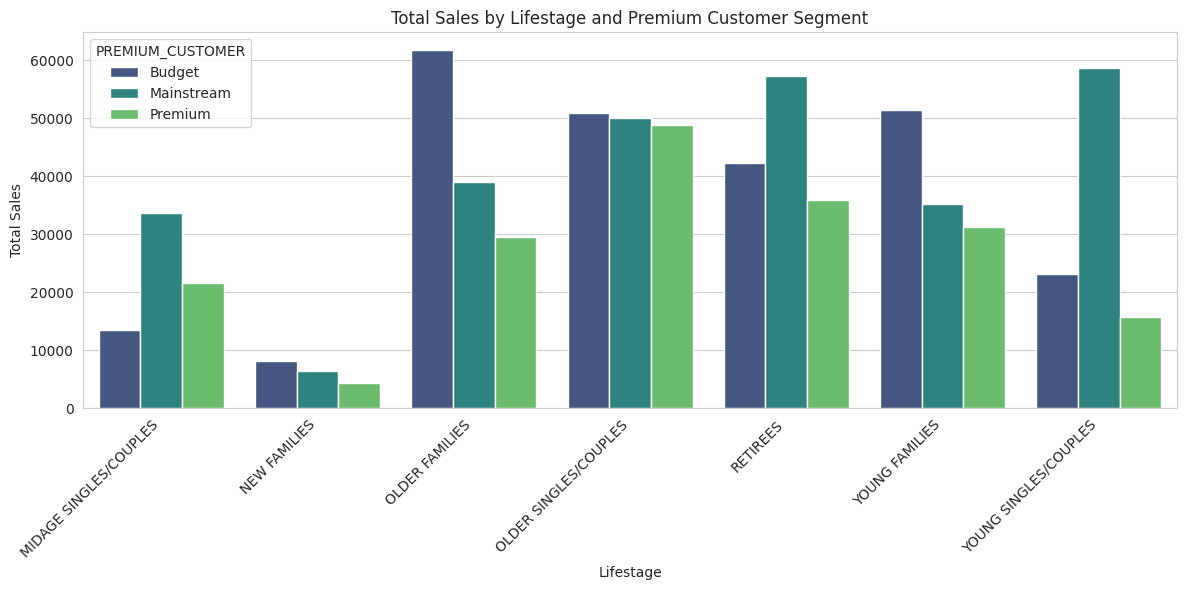

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style for the plots
sns.set_style("whitegrid")

# Create a grouped bar plot for total sales by lifestage and premium customer
plt.figure(figsize=(12, 6))
sns.barplot(data=sales_by_segment, x='LIFESTAGE', y='Total Sales', hue='PREMIUM_CUSTOMER', palette='viridis')
plt.title('Total Sales by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Total Sales')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyze Sales by Brand and Pack Size

Explore sales performance across different brands and pack sizes within each customer segment to identify product preferences. To analyze sales by brand and pack size within each customer segment, group the merged dataframe by `LIFESTAGE`, `PREMIUM_CUSTOMER`, `BRAND_NAME`, and `PACK_SIZE` and calculate the total sales.

In [ ]:
# Calculate total sales by lifestage, premium customer, brand, and pack size
sales_by_brand_pack = df_merged.groupby(['LIFESTAGE', 'PREMIUM_CUSTOMER', 'BRAND_NAME', 'PACK_SIZE'])['TOT_SALES'].sum().reset_index()

# Display top brands and pack sizes for a few key segments (e.g., Young Singles/Couples - Mainstream, Older Families - Budget)
print("\nTop Brands and Pack Sizes for Young Singles/Couples - Mainstream:")
display(sales_by_brand_pack[
    (sales_by_brand_pack['LIFESTAGE'] == 'YOUNG SINGLES/COUPLES') &
    (sales_by_brand_pack['PREMIUM_CUSTOMER'] == 'Mainstream')
].sort_values(by='TOT_SALES', ascending=False).head())

print("\nTop Brands and Pack Sizes for Older Families - Budget:")
display(sales_by_brand_pack[
    (sales_by_brand_pack['LIFESTAGE'] == 'OLDER FAMILIES') &
    (sales_by_brand_pack['PREMIUM_CUSTOMER'] == 'Budget')
].sort_values(by='TOT_SALES', ascending=False).head())

print("\nTop Brands and Pack Sizes for Retirees - Mainstream:")
display(sales_by_brand_pack[
    (sales_by_brand_pack['LIFESTAGE'] == 'RETIREES') &
    (sales_by_brand_pack['PREMIUM_CUSTOMER'] == 'Mainstream')
].sort_values(by='TOT_SALES', ascending=False).head())


Top Brands and Pack Sizes for Young Singles/Couples - Mainstream:


,LIFESTAGE,PREMIUM_CUSTOMER,BRAND_NAME,PACK_SIZE,TOT_SALES
366,YOUNG SINGLES/COUPLES,Mainstream,Kettle,150,7705.0
364,YOUNG SINGLES/COUPLES,Mainstream,Doritos,170,7669.2
375,YOUNG SINGLES/COUPLES,Mainstream,Thins,175,7217.1
361,YOUNG SINGLES/COUPLES,Mainstream,Cobs,110,6144.6
377,YOUNG SINGLES/COUPLES,Mainstream,Tyrrells,165,4800.6



Top Brands and Pack Sizes for Older Families - Budget:


,LIFESTAGE,PREMIUM_CUSTOMER,BRAND_NAME,PACK_SIZE,TOT_SALES
128,OLDER FAMILIES,Budget,Thins,175,7517.4
119,OLDER FAMILIES,Budget,Kettle,150,6826.4
117,OLDER FAMILIES,Budget,Doritos,170,6578.0
114,OLDER FAMILIES,Budget,Cobs,110,5658.2
130,OLDER FAMILIES,Budget,Tyrrells,165,4002.6



Top Brands and Pack Sizes for Retirees - Mainstream:


,LIFESTAGE,PREMIUM_CUSTOMER,BRAND_NAME,PACK_SIZE,TOT_SALES
261,RETIREES,Mainstream,Thins,175,7520.7
252,RETIREES,Mainstream,Kettle,150,7042.6
250,RETIREES,Mainstream,Doritos,170,6749.6
247,RETIREES,Mainstream,Cobs,110,5654.4
263,RETIREES,Mainstream,Tyrrells,165,4069.8


### Analyze Average Price per Unit

Calculate and visualize the average price paid per unit by customers in each segment to understand price sensitivity and product preferences. Use a grouped bar chart to visualize the `Average Price per Unit` for each `LIFESTAGE`, differentiated by `PREMIUM_CUSTOMER`.

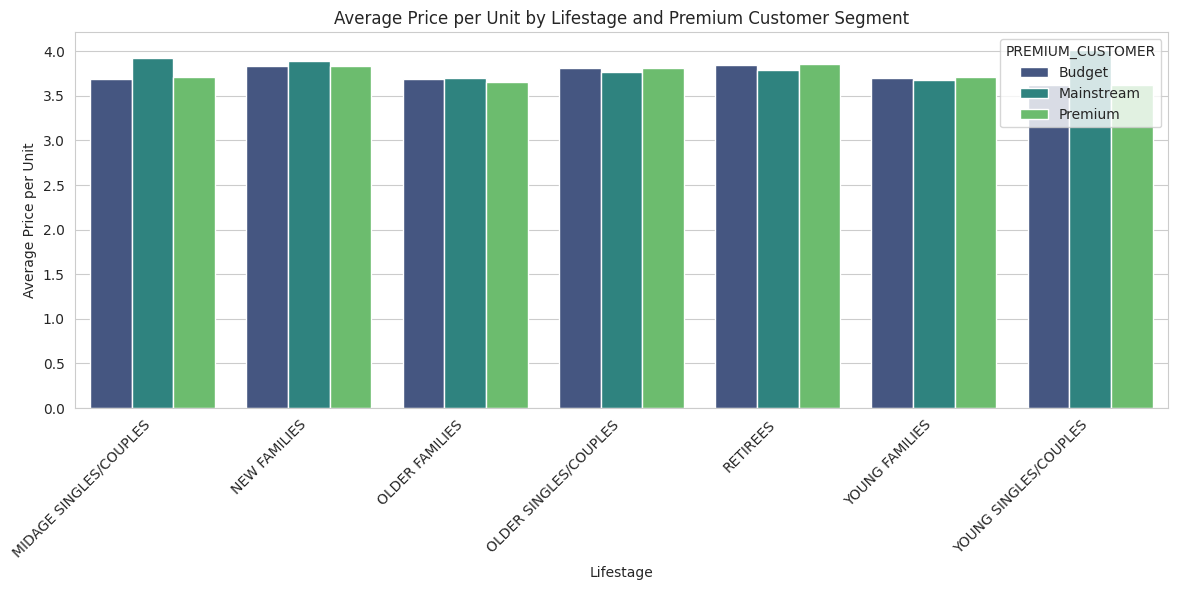

In [ ]:
# Create a grouped bar plot for the average price per unit by lifestage and premium customer
plt.figure(figsize=(12, 6))
sns.barplot(data=price_per_unit, x='LIFESTAGE', y='Average Price per Unit', hue='PREMIUM_CUSTOMER', palette='viridis')
plt.title('Average Price per Unit by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Average Price per Unit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyze Average Units per Customer

Calculate and visualize the average number of units purchased per customer in each segment to understand purchase volume. Use a grouped bar chart to visualize the `Average Units per Customer` for each `LIFESTAGE`, differentiated by `PREMIUM_CUSTOMER`.

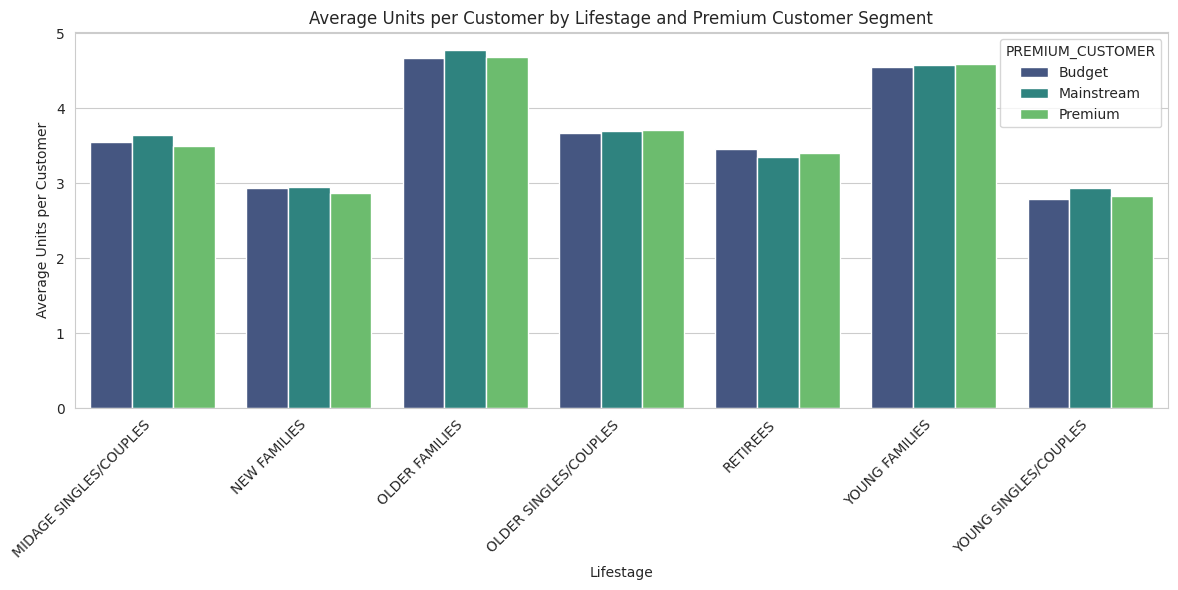

In [ ]:
# Create a grouped bar plot for the average units per customer by lifestage and premium customer
plt.figure(figsize=(12, 6))
sns.barplot(data=units_per_customer, x='LIFESTAGE', y='Average Units per Customer', hue='PREMIUM_CUSTOMER', palette='viridis')
plt.title('Average Units per Customer by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Average Units per Customer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Analyze Number of Customers by Segment

Analyze and visualize the number of customers in each segment to understand the size of each group. Use a grouped bar chart to visualize the number of customers for each `LIFESTAGE`, differentiated by `PREMIUM_CUSTOMER`.

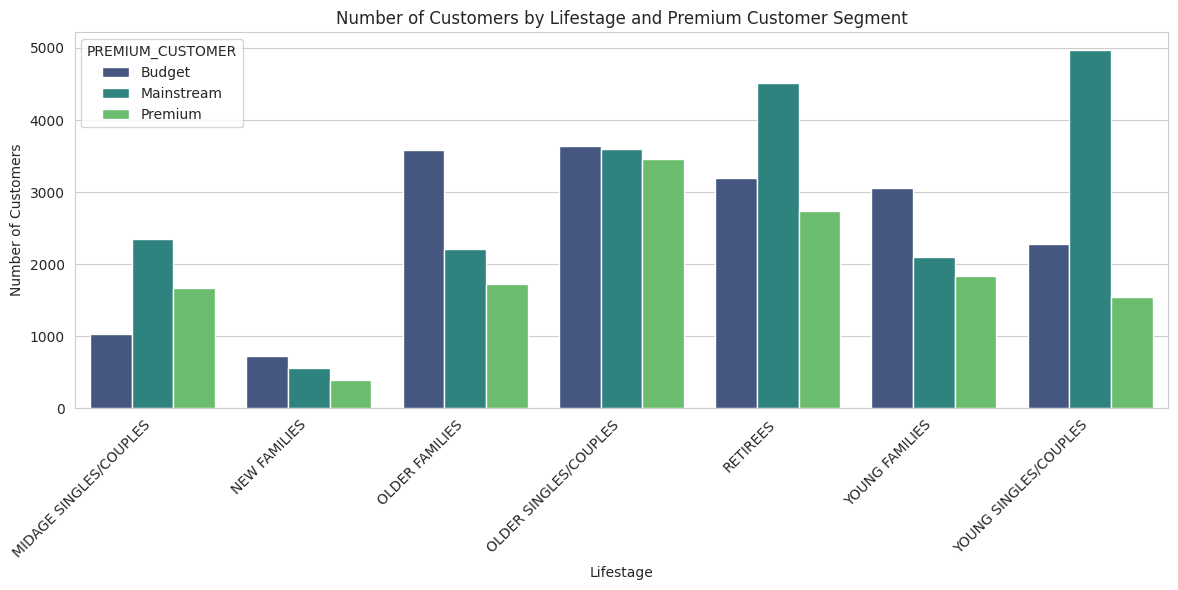

In [ ]:
# Create a grouped bar plot for the number of customers by lifestage and premium customer
plt.figure(figsize=(12, 6))
sns.barplot(data=customers_by_segment, x='LIFESTAGE', y='Number of Customers', hue='PREMIUM_CUSTOMER', palette='viridis')
plt.title('Number of Customers by Lifestage and Premium Customer Segment')
plt.xlabel('Lifestage')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Summary of Findings:

**Key Insights and Drivers:**

*   **Overall Sales Performance**: Older Families - Budget, Young Singles/Couples - Mainstream, and Retirees - Mainstream are the top segments by total sales.
*   **Customer Base Size**: Young Singles/Couples - Mainstream and Retirees - Mainstream have the largest customer bases.
*   **Purchase Volume**: Older Families and Young Families tend to buy more units per customer.
*   **Price Sensitivity**: Young Singles/Couples - Mainstream pay a slightly higher average price per unit, potentially indicating a preference for premium or larger pack size chips.
*   **Brand and Pack Size Preferences**:
    *   Young Singles/Couples - Mainstream show high sales for Kettle 150g, Doritos 170g, and Thins 175g.
    *   Older Families - Budget show high sales for Thins 175g, Kettle 150g, and Doritos 170g.
    *   Retirees - Mainstream show high sales for Thins 175g, Kettle 150g, and Doritos 170g.

Based on these observations, some potential drivers of sales could be:

*   **Segment Size**: Larger segments like Young Singles/Couples - Mainstream and Retirees - Mainstream contribute significantly to total sales simply due to the number of customers.
*   **Purchase Volume**: Segments like Older Families and Young Families, who buy more units per customer, are important for driving sales volume.
*   **Price/Product Preference**: The slightly higher average price per unit in Young Singles/Couples - Mainstream suggests they may be drawn to certain brands or pack sizes that command a higher price, which contributes to their high total sales. The consistent popularity of brands like Kettle, Doritos, and Thins across different top segments indicates strong brand loyalty or broad appeal.
*   **Budget Segment Behavior**: The high total sales in the Older Families - Budget segment, despite not having the largest customer base, suggests a strong combination of purchase frequency and units per purchase within this budget-conscious group.

**Summary of analysis:**

*   **Top Segments:** Older Families - Budget, Young Singles/Couples - Mainstream, and Retirees - Mainstream are the top segments by total sales.
*   **Sales Drivers:** High sales are influenced by segment size (Young Singles/Couples - Mainstream, Retirees - Mainstream), purchase volume (Older Families, Young Families), and price/product preference (Young Singles/Couples - Mainstream pay slightly more per unit, and Kettle, Doritos, and Thins in 150g/175g sizes are popular).

These insights suggest that both the size of the customer segment and their purchasing behavior (volume and price sensitivity) are key drivers of sales. The popularity of specific brands and pack sizes also plays a significant role.

## Recommendations

Based on the analysis of sales performance, customer behavior, and product preferences across different segments, some of the actionable recommendations for targeting key customer groups and strategies to optimize the chip category's performance are:

**Actionable Recommendations:**

Based on the analysis, the following recommendations are proposed:

1.  **Target Top-Performing Segments**:
    *   **Older Families - Budget**: Focus on maintaining availability of popular budget-friendly brands and pack sizes. Consider targeted promotions or loyalty programs that resonate with this price-sensitive group who purchase in higher volumes.
    *   **Young Singles/Couples - Mainstream**: Leverage their higher price per unit and preference for certain brands (Kettle, Doritos, Thins) and pack sizes (150g, 170g, 175g). Marketing efforts could highlight new or premium varieties within these popular brands. Consider online marketing and social media campaigns as this segment is likely tech-savvy.
    *   **Retirees - Mainstream**: Continue to cater to their preference for popular brands and pack sizes. In-store promotions and easy accessibility of these products could be effective.
2.  **Increase Purchase Volume in Other Segments**: For segments with lower average units per customer (e.g., Young Singles/Couples - Budget/Premium, Retirees - Budget/Premium), consider strategies like multi-buy offers or bundle deals to encourage purchasing more units per transaction.
3.  **Optimize Product Assortment**: Ensure the availability of popular brands (Kettle, Doritos, Thins) and pack sizes (150g, 170g, 175g) across all stores, especially those frequented by the top-performing segments. Explore introducing new flavors or variations within these popular lines.
4.  **Tailor Marketing Messages**: Develop marketing campaigns that resonate with the specific lifestage and premium customer segments. For example, campaigns for Older Families could emphasize value and family-size packs, while those for Young Singles/Couples could focus on convenience and trendy flavors.
5.  **Monitor and Adapt**: Continuously monitor sales performance and customer behavior across segments. Be prepared to adapt strategies based on changing trends and preferences.

These recommendations aim to capitalize on the strengths of the top-performing segments while also exploring opportunities to increase sales and engagement in other customer groups, ultimately driving overall growth in the chip category.

## Summary of Steps, Insights, and Recommendations

This analysis aimed to understand chip customer purchasing behavior to inform the supermarket’s strategic plan for the chip category.

**Steps Performed:**

1.  **Data Loading and Cleaning**: Loaded transaction and customer data, checked for missing values, examined product names, and handled outliers.
2.  **Feature Engineering**: Extracted `PACK_SIZE` and `BRAND_NAME` from product names.
3.  **Metric Definition**: Defined key metrics including total sales, number of customers, average units per customer, and average price per unit by customer segment.
4.  **Segment Analysis**: Analyzed and visualized sales, customer counts, average units, and average price across different Lifestage and Premium Customer segments. Explored sales by brand and pack size within key segments.

**Key Insights and Drivers:**

*   **Top Segments**: Older Families - Budget, Young Singles/Couples - Mainstream, and Retirees - Mainstream are the top segments by total sales.
*   **Sales Drivers**: High sales are driven by a combination of segment size (Young Singles/Couples - Mainstream, Retirees - Mainstream) and purchase volume (Older Families, Young Families). Price sensitivity and brand/pack size preferences also play a role, with Young Singles/Couples - Mainstream showing a slightly higher average price per unit and consistent popularity of Kettle, Doritos, and Thins across top segments.
*   **Product Preferences**: Kettle, Doritos, and Thins, particularly in 150g and 175g pack sizes, are popular across top-performing segments.

**Recommendations:**

1.  **Target Top Segments**: Tailor strategies for Older Families - Budget (value focus), Young Singles/Couples - Mainstream (premium/popular brands, online marketing), and Retirees - Mainstream (convenience, in-store promotions).
2.  **Increase Purchase Volume**: Implement multi-buy offers or bundle deals for segments with lower average units per customer.
3.  **Optimize Assortment**: Ensure availability of popular brands and pack sizes, and explore new variations within popular lines.
4.  **Tailor Marketing**: Develop segment-specific marketing messages.
5.  **Monitor and Adapt**: Continuously track performance and adjust strategies as needed.

These findings and recommendations provide a solid foundation for the Chips Category Manager to develop effective strategies for the next six months, focusing on key customer segments and leveraging insights into their purchasing behavior and product preferences.